Data Visualization

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Detected classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


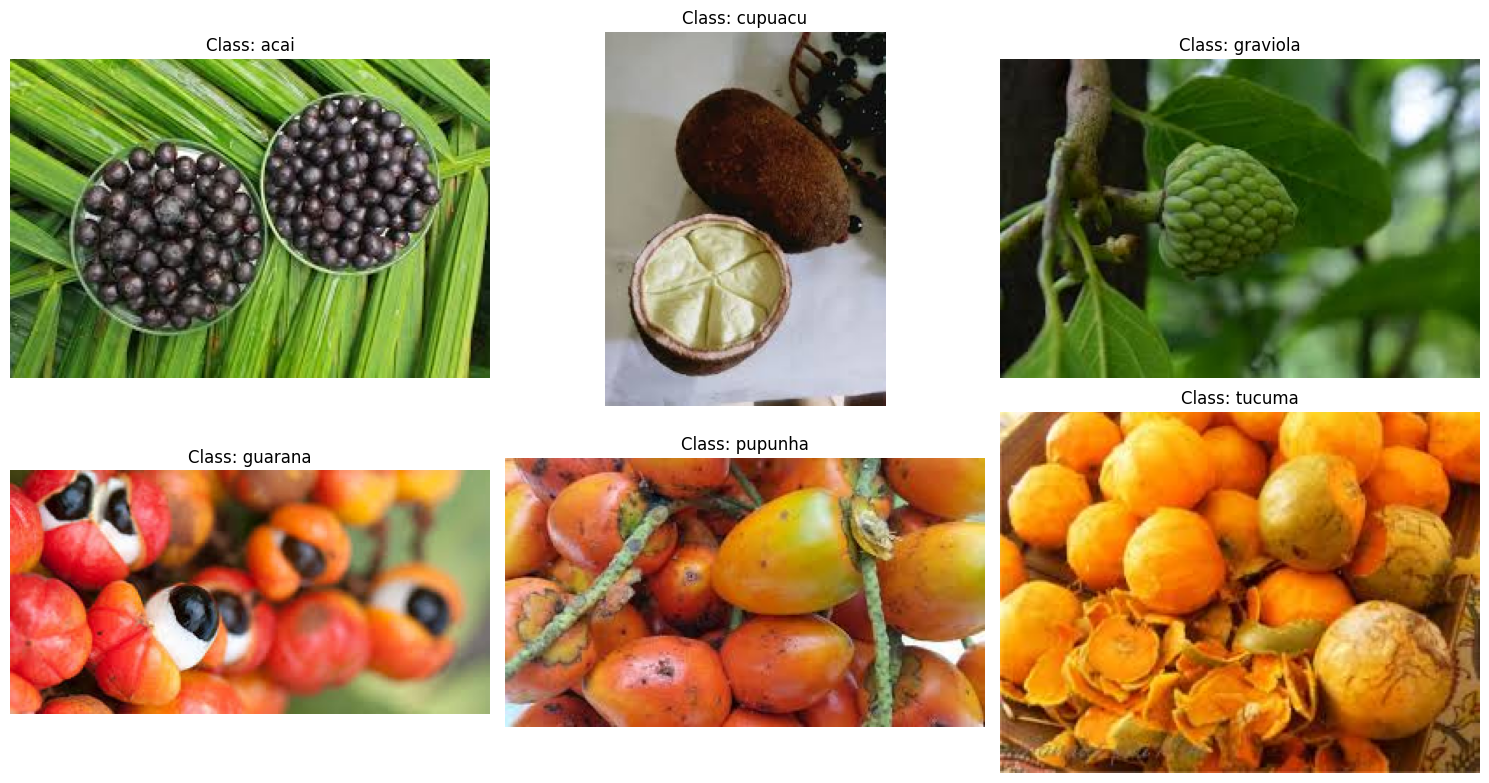

In [4]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#Defining path to training data
train_dir = '/content/drive/MyDrive/Artificial-Intelligence-And-Machine-Learning-Materials/Week 5/FruitinAmazon/train'

# Get the list of class directories
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
classes.sort() #to keep the order consistent

print(f"Detected classes: {classes}")

# Set up the visualization grid (two rows)
num_classes = len(classes)
cols = (num_classes + 1) //2 #Ceiling division to ensure all classes fit

plt.figure(figsize=(15, 8))
for i, class_name in enumerate(classes):
  class_path = os.path.join(train_dir, class_name)
  #Get all images in this class folder
  images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

  if images:
    #Select one image randomly
    random_img_name = random.choice(images)
    img_path = os.path.join(class_path, random_img_name)

    #load and plot
    img = mpimg.imread(img_path)

    plt.subplot(2, cols, i+1)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis('off')
plt.tight_layout()
plt.show()


**What did you observe?**

In this given image, we can see that 6 images are being plotted in 3 row with random choice.

Checking for corrupt image

In [5]:
from PIL import Image

#List to keep track of removed files
corrupted_images = []

for class_name in classes:
  class_path = os.path.join(train_dir, class_name)
  #Skip directories, check only files
  for filename in os.listdir(class_path):
    image_path = os.path.join(class_path, filename)

    if os.path.isfile(image_path):
      try:
        #Attempt to open and verify the image
        with Image.open(image_path) as img:
          img.verify() #verify image content without loading the whole file
      except (IOError, SyntaxError) as e:
        #if error is raised, file is likely corrupted
        os.remove(image_path)
        corrupted_images.append(image_path)
        print(f"Removed corrupt image: {image_path}")
#final Reporting
if not corrupted_images:
  print("No corrupt images found")
else:
  print(f"Total number of removed images: {len(corrupted_images)}")

No corrupt images found


Sample

In [38]:
import tensorflow as tf

# Define image size and batch size

img_height = 224 # Example image height
img_width = 224 # Example image width
batch_size = 16 # Corrected: Defined batch_size
validation_split = 0.2 # 80% training, 20% validation

# Create a preprocessing layer for normalization

# rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]

# Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size, # Use the defined batch_size
  shuffle=True,
  validation_split=validation_split,
  subset='training',
  seed=123
)

# Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size, # Use the defined batch_size
  shuffle=False,
  validation_split=validation_split,
  subset='validation',
  seed=123
)

# train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Optimize for performance
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [39]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [43]:
from tensorflow.keras import layers, models

model = models.Sequential()

# Input + Augmentation + Rescaling
model.add(layers.Input(shape=(224, 224, 3)))
model.add(data_augmentation)

# Conv Block 1
model.add(layers.Rescaling(1./255))
model.add(layers.Conv2D(32, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D())
model.add(layers.Dropout(0.25))

# Conv Block 2
model.add(layers.Conv2D(64, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D())
model.add(layers.Dropout(0.25))

# Conv Block 3 (FIXED)
model.add(layers.Conv2D(128, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D())
model.add(layers.Dropout(0.25))

# Dense part
model.add(layers.Flatten())

model.add(layers.Dense(256))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.5))

# Output layer (VERY IMPORTANT)
model.add(layers.Dense(len(classes), activation='softmax'))

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_13 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_10 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 6)              │         1,54

 Total params: 25,787,078 (98.37 MB)

 Trainable params: 25,786,118 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [44]:
# Compiling the model with the requested parameters
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


Task 4: Train the Model
Model Training
• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.
• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

Starting training...
Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2201 - loss: 2.6368
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_fruit_model.keras

Epoch 1: finished saving model to best_fruit_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - accuracy: 0.3194 - loss: 2.3894 - val_accuracy: 0.1667 - val_loss: 1.5149
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4906 - loss: 1.5286
Epoch 2: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.4583 - loss: 1.4994 - val_accuracy: 0.1667 - val_loss: 1.4824
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6389 - loss: 1.0198
Epoch 3: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.6528 - loss: 1.0339 - val_accuracy: 0.0000e+00 - val_loss: 1.5669
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6365 - loss: 0.8746
Epoch 4: val_accuracy did not improve from 0.16667
5/5 ━

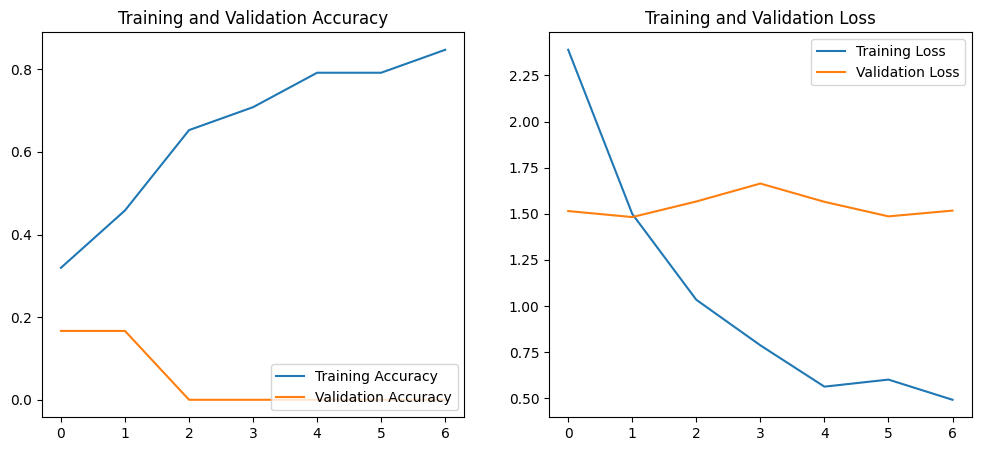

In [45]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

# 1. Define the Callbacks
# EarlyStopping: Prevents the model from training for 250 epochs if it stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ModelCheckpoint: Saves the 'gold medal' version of your model
checkpoint = ModelCheckpoint(
    'best_fruit_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2. Execute Training
# Your train_ds already contains the batch_size (16) and shuffling logic
epochs = 250

print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping, checkpoint],
    )

# 3. Visuali-ze Training Results (Optional but helpful for Task 5)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()

Task 6: Save and Load the Model
Model Saving and Loading
• Save the trained model to an .h5 file using model.save().
• Load the saved model and re-evaluate its performance on the test set.

In [ ]:
import tensorflow as tf

# Define path to the test folder
test_dir = '/content/drive/MyDrive/Ai last sem/FruitinAmazon/FruitinAmazon/test'

# Create the test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224), # Must match training size
    interpolation='nearest',
    batch_size=32,         # Matching your requested training batch size
    shuffle=False          # No need to shuffle for testing
)

# Normalize the test images (Crucial step!)
normalization_layer = tf.keras.layers.Rescaling(1./255)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Found 30 files belonging to 6 classes.


In [ ]:
import tensorflow as tf


# 1. Save the model to an .h5 file
model_filename = 'fruit_classifier_model.h5'
model.save(model_filename)
print(f"Model saved successfully to {model_filename}")

# 2. Load the saved model
# This creates a new 'loaded_model' object independent of the original 'model'
loaded_model = tf.keras.models.load_model(model_filename)
print("Model loaded successfully.")

# 3. Re-evaluate on the test set
# We use the test_ds we created in Task 5
print("\n--- Re-evaluating Loaded Model ---")
loss, accuracy = loaded_model.evaluate(test_ds)

print(f"Loaded Model Test Accuracy: {accuracy * 100:.2f}%")

Model saved successfully to fruit_classifier_model.h5
Model loaded successfully.

--- Re-evaluating Loaded Model ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.8333 - loss: 0.5850
Loaded Model Test Accuracy: 83.33%


Implementation Task 7


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       0.71      1.00      0.83         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.60      0.75         5
     pupunha       0.71      1.00      0.83         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.83        30
   macro avg       0.88      0.83      0.82        30
weighted avg       0.88      0.83      0.82        30


CONFUSION MATRIX
[[5 0 0 0 0 0]
 [0 5 0 0 0 0]
 [0 0 5 0 0 0]
 [0 0 0 3 2 0]
 [0 0 0 0 5 0]
 [1 2 0 0 0 2]]


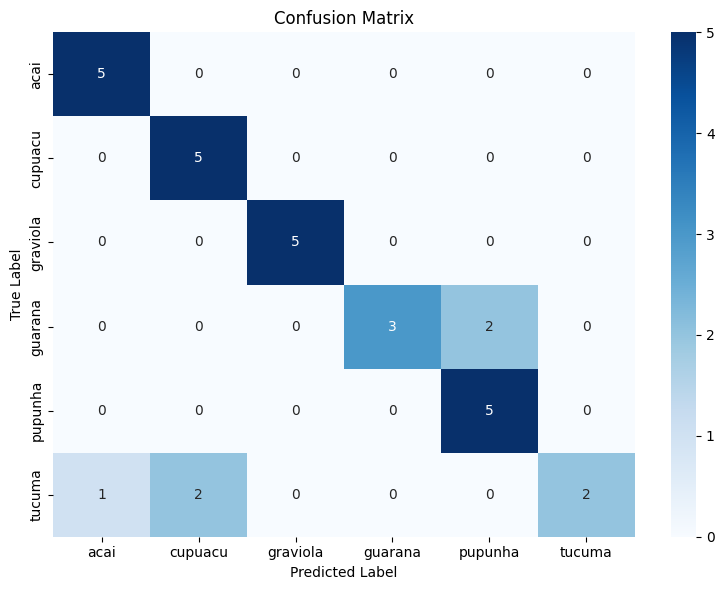

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get the true labels and images from the test set
y_true = []
y_pred = []

# Loop through the test dataset to get predictions
for images, labels in test_ds:
    # Make predictions
    preds = loaded_model.predict(images, verbose=0)  # verbose=0 for cleaner output

    # Convert probabilities to digit labels
    pred_labels = np.argmax(preds, axis=1)

    # Store results
    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

# Generate classification report
# The original image_dataset_from_directory has class_names, but after .map() it becomes a _MapDataset
# The `classes` variable is already available in the kernel from a previous cell.
class_names = classes

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

# Optional: Confusion Matrix for better visualization
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Optional: Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Task 2    

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Load pre-trained VGG16 (without top layers)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# 3. Add custom classification head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(classes), activation='softmax')(x)

# 4. Create final model
transfer_model = Model(inputs=base_model.input, outputs=outputs)

# 5. Compile
transfer_model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 6. Train
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)]
)

# 7. Evaluate
transfer_loss, transfer_acc = transfer_model.evaluate(test_ds)
print(f"Transfer Learning Test Accuracy: {transfer_acc:.4f}")

# 8. Classification Report for transfer model
# (Similar loop as before but with transfer_model)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
# model.fit(train_ds, validation_data=val_ds, epochs=...)